# LinearSVM Training for PTM Prediction

This notebook trains Linear Support Vector Machine (SVM) models using SGDClassifier with hinge loss for multi-label classification of protein post-translational modifications.

## Overview
- **Task**: Multi-label binary classification (3 labels)
- **Model**: LinearSVM (SGDClassifier with hinge loss)
- **Challenge**: Severe class imbalance (1:7 to 1:25 ratios)
- **Solution**: `class_weight='balanced'` to handle imbalance
- **Encodings**: Trains on ALL 4 encodings (onehot, blosum, aapc, hybrid)

## Why LinearSVM (SGDClassifier)?

**Advantages over Random Forest and XGBoost:**
- **Scalability**: Extremely fast on large datasets (70K samples)
- **Linear decision boundary**: Works well for high-dimensional encoded features
- **Memory efficient**: No need to store entire forest of trees
- **Proven for text/sequence data**: SVMs excel at high-dimensional sparse features

**SGDClassifier with hinge loss = Linear SVM:**
- Stochastic Gradient Descent implementation
- Scales to 70K+ samples efficiently
- Online learning capability

## Labels to Predict:
1. S-glutathionylation (very rare: ~5% positive)
2. S-nitrosylation (rare: ~12% positive)
3. S-palmitoylation (very rare: ~3% positive)

## Encodings:
1. **onehot**: One-hot encoding (113 features)
2. **blosum**: BLOSUM62 matrix (658 features)
3. **aapc**: Amino acid pair composition (438 features)
4. **hybrid**: Hybrid encoding (658 features)

## 1. Configuration

In [1]:
import os

# ============================================================================
# CONFIGURATION PARAMETERS
# ============================================================================

# Encodings to train on (will loop through all)
ENCODING_MTHD = 

# SVM Hyperparameters
MAX_ITER = 1000              # Maximum iterations for SGD
PENALTY = 'l2'               # Regularization: 'l1', 'l2', or 'elasticnet'
ALPHA = 0.0001               # Regularization strength
LEARNING_RATE = 'optimal'    # Learning rate schedule

# Computing resources
N_CORES = 16
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["MKL_NUM_THREADS"] = str(N_CORES)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_CORES)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_CORES)
os.environ["NUMEXPR_NUM_THREADS"] = str(N_CORES)

# Random state
RANDOM_STATE = 42

print("Configuration loaded:")
print(f"  Encodings: {ENCODINGS}")
print(f"  Max iterations: {MAX_ITER}")
print(f"  Penalty: {PENALTY}")
print(f"  Alpha: {ALPHA}")
print(f"  Learning rate: {LEARNING_RATE}")

Configuration loaded:
  Encodings: ['onehot', 'blosum', 'aapc', 'hybrid']
  Max iterations: 1000
  Penalty: l2
  Alpha: 0.0001
  Learning rate: optimal


## 2. Import Libraries

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    roc_auc_score, 
    hamming_loss,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 3. Helper Functions

We need functions to:
1. Create train/val splits for encodings that don't have them
2. Prepare features (convert booleans, remove non-numeric columns)
3. Calculate class weights for imbalanced data

In [ ]:
def create_train_val_split(df, test_size=0.2, random_state=42):
    """
    Create stratified train/val split for multi-label data.
    Uses simple stratification on total modification count.
    """
    label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']
    
    # Stratify on total modification count
    df['total_mods'] = df[label_cols].sum(axis=1)
    
    train_df, val_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df['total_mods'],
        random_state=random_state
    )
    
    # Remove temporary column
    train_df = train_df.drop('total_mods', axis=1).reset_index(drop=True)
    val_df = val_df.drop('total_mods', axis=1).reset_index(drop=True)
    
    return train_df, val_df


In [3]:
def prepare_features(train_df, val_df):
    """
    Prepare features for SVM training.
    
    Steps:
    1. Separate features from labels
    2. Convert boolean columns to integers
    3. Remove non-numeric columns
    4. Convert to numpy arrays
    
    Returns:
        X_train, X_val, y_train, y_val, feature_cols
    """
    label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']
    
    # Get feature columns (everything except ID, Sequence, and labels)
    feature_cols = [col for col in train_df.columns 
                    if col not in ['ID', 'Sequence'] + label_cols]
    
    # Extract features
    X_train_df = train_df[feature_cols].copy()
    X_val_df = val_df[feature_cols].copy()
    
    # Convert boolean columns to integers
    bool_cols = X_train_df.select_dtypes(include=['bool']).columns
    if len(bool_cols) > 0:
        for col in bool_cols:
            X_train_df[col] = X_train_df[col].astype(int)
            X_val_df[col] = X_val_df[col].astype(int)
    
    # Remove non-numeric columns
    non_numeric = X_train_df.select_dtypes(include=['object']).columns
    if len(non_numeric) > 0:
        X_train_df = X_train_df.drop(columns=non_numeric)
        X_val_df = X_val_df.drop(columns=non_numeric)
        feature_cols = [col for col in feature_cols if col not in non_numeric]
    
    # Convert to numpy arrays
    X_train = X_train_df.values.astype(float)
    X_val = X_val_df.values.astype(float)
    y_train = train_df[label_cols].values
    y_val = val_df[label_cols].values
    
    return X_train, X_val, y_train, y_val, feature_cols


print("✓ Helper functions defined")

✓ Helper functions defined


## 4. Train SVM Models on All Encodings

We'll loop through all 4 encodings and train separate SVM models for each.

For each encoding, we:
1. Load or create train/val split
2. Prepare features
3. Train 3 binary SVM classifiers (one per label)
4. Evaluate on validation set
5. Save models and predictions

In [4]:
# Dictionary to store results across all encodings
all_results = {}

# Loop through each encoding
for encoding in ENCODINGS:
    print("\n" + "="*80)
    print(f"TRAINING LINEAR SVM ON {encoding.upper()} ENCODING")
    print("="*80)
    
    # Define paths
    train_path = f"../data_engineered/{encoding}/train_with_features_{encoding}_split.csv"
    val_path = f"../data_engineered/{encoding}/val_with_features_{encoding}_split.csv"
    full_data_path = f"../data_engineered/{encoding}/train_with_features_{encoding}.csv"
    output_dir = f"../output/svm/{encoding}"
    
    # Create output directory
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # ========================================================================
    # Step 1: Load or Create Train/Val Split
    # ========================================================================
    print(f"\nStep 1: Loading data...")
    
    if Path(train_path).exists() and Path(val_path).exists():
        print(f"  ✓ Found existing splits")
        train_df = pd.read_csv(train_path)
        val_df = pd.read_csv(val_path)
    elif Path(full_data_path).exists():
        print(f"  ⚠️  No splits found. Creating train/val split...")
        full_df = pd.read_csv(full_data_path)
        train_df, val_df = create_train_val_split(full_df, test_size=0.2, random_state=RANDOM_STATE)
        
        # Save splits for future use
        train_df.to_csv(train_path, index=False)
        val_df.to_csv(val_path, index=False)
        print(f"  ✓ Created and saved splits")
    else:
        print(f"  ✗ ERROR: Could not find data for {encoding} encoding")
        print(f"    Expected: {full_data_path}")
        print(f"    Skipping this encoding...")
        continue
    
    print(f"  Training samples: {len(train_df):,}")
    print(f"  Validation samples: {len(val_df):,}")
    
    # ========================================================================
    # Step 2: Prepare Features
    # ========================================================================
    print(f"\nStep 2: Preparing features...")
    
    X_train, X_val, y_train, y_val, feature_cols = prepare_features(train_df, val_df)
    
    print(f"  ✓ Features prepared")
    print(f"    Shape: {X_train.shape} (samples, features)")
    print(f"    Total features: {len(feature_cols)}")
    
    # ========================================================================
    # Step 3: Examine Class Imbalance
    # ========================================================================
    print(f"\nStep 3: Class distribution:")
    
    label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']
    for idx, label in enumerate(label_cols):
        pos_count = y_train[:, idx].sum()
        neg_count = len(y_train) - pos_count
        ratio = neg_count / pos_count
        print(f"  {label}: {pos_count:,} pos / {neg_count:,} neg (1:{ratio:.1f})")
    
    # ========================================================================
    # Step 4: Train SVM Models (3 binary classifiers)
    # ========================================================================
    print(f"\nStep 4: Training SVM models...")
    
    models = {}
    
    for idx, label in enumerate(label_cols):
        print(f"  Training {label}...", end=" ")
        
        # Initialize LinearSVM using SGDClassifier
        svm = SGDClassifier(
            loss='hinge',                    # Linear SVM loss function
            penalty=PENALTY,                 # Regularization type
            alpha=ALPHA,                     # Regularization strength
            max_iter=MAX_ITER,               # Maximum iterations
            class_weight='balanced',         # Handle class imbalance
            random_state=RANDOM_STATE,
            learning_rate=LEARNING_RATE,
            n_jobs=N_CORES,
            verbose=0
        )
        
        # Train
        svm.fit(X_train, y_train[:, idx])
        models[label] = svm
        
        print("✓")
    
    print(f"  ✓ All models trained")
    
    # ========================================================================
    # Step 5: Evaluate on Validation Set
    # ========================================================================
    print(f"\nStep 5: Evaluating models...")
    
    results = {}
    val_predictions = {}
    
    for idx, label in enumerate(label_cols):
        model = models[label]
        
        # Get predictions
        y_pred = model.predict(X_val)
        y_pred_proba = model.decision_function(X_val)  # SVM decision scores
        
        # Normalize decision function to [0, 1] for consistency
        # Use sigmoid transformation
        y_pred_proba_norm = 1 / (1 + np.exp(-y_pred_proba))
        
        # Calculate metrics
        f1 = f1_score(y_val[:, idx], y_pred)
        auc = roc_auc_score(y_val[:, idx], y_pred_proba_norm)
        
        results[label] = {'f1': f1, 'auc': auc}
        val_predictions[label] = y_pred_proba_norm
        
        print(f"  {label}:")
        print(f"    F1-score: {f1:.4f}")
        print(f"    ROC-AUC:  {auc:.4f}")
    
    # Multi-label metrics
    all_preds = np.column_stack([val_predictions[label] for label in label_cols])
    all_preds_binary = (all_preds > 0.5).astype(int)
    
    hamming = hamming_loss(y_val, all_preds_binary)
    subset_acc = np.mean(np.all(all_preds_binary == y_val, axis=1))
    
    macro_f1 = np.mean([results[label]['f1'] for label in label_cols])
    macro_auc = np.mean([results[label]['auc'] for label in label_cols])
    
    print(f"\n  Overall Performance:")
    print(f"    Macro F1:        {macro_f1:.4f}")
    print(f"    Macro AUC:       {macro_auc:.4f}")
    print(f"    Hamming Loss:    {hamming:.4f}")
    print(f"    Subset Accuracy: {subset_acc:.4f}")
    
    # ========================================================================
    # Step 6: Feature Importance (SVM Coefficients)
    # ========================================================================
    print(f"\nStep 6: Extracting feature importance...")
    
    feature_importance = {}
    for label in label_cols:
        model = models[label]
        # SVM coefficients represent feature importance
        coef = np.abs(model.coef_[0])  # Take absolute values
        feature_importance[label] = coef
    
    print(f"  ✓ Feature importance extracted")
    
    # ========================================================================
    # Step 7: Save Models and Results
    # ========================================================================
    print(f"\nStep 7: Saving outputs...")
    
    # Save models
    with open(f"{output_dir}/svm_models.pkl", 'wb') as f:
        pickle.dump(models, f)
    print(f"  ✓ Models saved to {output_dir}/svm_models.pkl")
    
    # Save validation predictions
    val_pred_df = pd.DataFrame({
        'ID': val_df['ID'],
        'svm_glut_proba': val_predictions['S-glutathionylation'],
        'svm_nitro_proba': val_predictions['S-nitrosylation'],
        'svm_palm_proba': val_predictions['S-palmitoylation']
    })
    val_pred_df.to_csv(f"{output_dir}/svm_val_predictions.csv", index=False)
    print(f"  ✓ Predictions saved to {output_dir}/svm_val_predictions.csv")
    
    # Save results summary
    results_df = pd.DataFrame(results).T
    results_df.to_csv(f"{output_dir}/svm_results.csv")
    print(f"  ✓ Results saved to {output_dir}/svm_results.csv")
    
    # Save feature importance
    for label in label_cols:
        fi_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': feature_importance[label]
        }).sort_values('importance', ascending=False)
        
        label_short = label.replace('S-', '').replace('-', '_')
        fi_df.to_csv(f"{output_dir}/svm_feature_importance_{label_short}.csv", index=False)
    
    print(f"  ✓ Feature importance saved")
    
    # Store results for summary
    all_results[encoding] = {
        'macro_f1': macro_f1,
        'macro_auc': macro_auc,
        'hamming_loss': hamming,
        'subset_accuracy': subset_acc,
        'per_label': results
    }
    
    print(f"\n✓ {encoding.upper()} ENCODING COMPLETE!")

print("\n" + "="*80)
print("ALL ENCODINGS PROCESSED!")
print("="*80)


TRAINING LINEAR SVM ON ONEHOT ENCODING

Step 1: Loading data...
  ✓ Found existing splits
  Training samples: 71,208
  Validation samples: 17,802

Step 2: Preparing features...
  ✓ Features prepared
    Shape: (71208, 109) (samples, features)
    Total features: 109

Step 3: Class distribution:
  S-glutathionylation: 3,786 pos / 67,422 neg (1:17.8)
  S-nitrosylation: 8,845 pos / 62,363 neg (1:7.1)
  S-palmitoylation: 2,662 pos / 68,546 neg (1:25.7)

Step 4: Training SVM models...
  Training S-glutathionylation... ✓
  Training S-nitrosylation... ✓
  Training S-palmitoylation... ✓
  ✓ All models trained

Step 5: Evaluating models...
  S-glutathionylation:
    F1-score: 0.1145
    ROC-AUC:  0.7043
  S-nitrosylation:
    F1-score: 0.2218
    ROC-AUC:  0.7153
  S-palmitoylation:
    F1-score: 0.1115
    ROC-AUC:  0.6871

  Overall Performance:
    Macro F1:        0.1493
    Macro AUC:       0.7022
    Hamming Loss:    0.4494
    Subset Accuracy: 0.1129

Step 6: Extracting feature importan

## 5. Compare Performance Across Encodings

Now let's compare SVM performance across all 4 encodings to see which encoding works best.

In [5]:
print("\n" + "="*80)
print("SUMMARY: SVM PERFORMANCE ACROSS ALL ENCODINGS")
print("="*80)

# Create summary table
summary_data = []
for encoding, res in all_results.items():
    summary_data.append({
        'Encoding': encoding,
        'Macro F1': res['macro_f1'],
        'Macro AUC': res['macro_auc'],
        'Hamming Loss': res['hamming_loss'],
        'Subset Accuracy': res['subset_accuracy']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Macro F1', ascending=False)

print("\n" + summary_df.to_string(index=False))

# Save summary
Path("../output/svm").mkdir(parents=True, exist_ok=True)
summary_df.to_csv("../output/svm/svm_encoding_comparison.csv", index=False)
print(f"\n✓ Saved comparison to ../output/svm/svm_encoding_comparison.csv")

# Find best encoding
best_encoding = summary_df.iloc[0]['Encoding']
best_f1 = summary_df.iloc[0]['Macro F1']
print(f"\n🏆 Best encoding: {best_encoding} (Macro F1: {best_f1:.4f})")


SUMMARY: SVM PERFORMANCE ACROSS ALL ENCODINGS

Encoding  Macro F1  Macro AUC  Hamming Loss  Subset Accuracy
  onehot  0.149267   0.702205      0.449444         0.112909
  blosum  0.082706   0.690153      0.329401         0.191271
    aapc  0.082706   0.690153      0.329401         0.191271
  hybrid  0.082706   0.690153      0.329401         0.191271

✓ Saved comparison to ../output/svm/svm_encoding_comparison.csv

🏆 Best encoding: onehot (Macro F1: 0.1493)


## 6. Visualize Results

Create comparison plots across encodings.

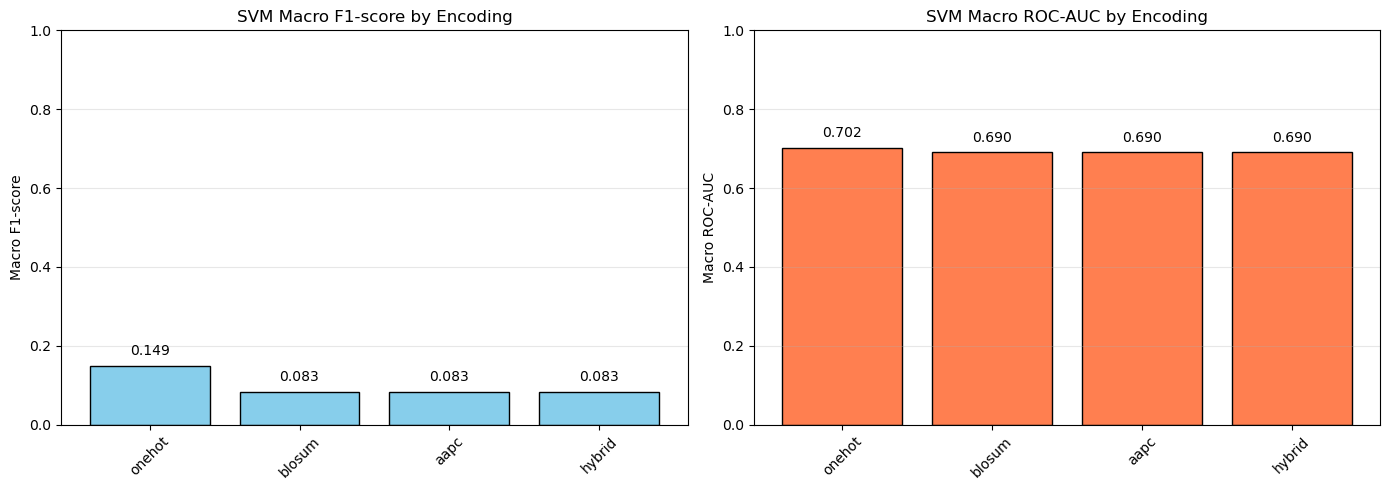

✓ Visualization saved


In [6]:
# Create visualization directory
Path("../output/svm/visualizations").mkdir(parents=True, exist_ok=True)

# Plot 1: Macro F1 and AUC across encodings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

encodings = summary_df['Encoding'].values
f1_scores = summary_df['Macro F1'].values
auc_scores = summary_df['Macro AUC'].values

# F1 scores
axes[0].bar(range(len(encodings)), f1_scores, color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(encodings)))
axes[0].set_xticklabels(encodings, rotation=45)
axes[0].set_ylabel('Macro F1-score')
axes[0].set_title('SVM Macro F1-score by Encoding')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# AUC scores
axes[1].bar(range(len(encodings)), auc_scores, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(encodings)))
axes[1].set_xticklabels(encodings, rotation=45)
axes[1].set_ylabel('Macro ROC-AUC')
axes[1].set_title('SVM Macro ROC-AUC by Encoding')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(auc_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("../output/svm/visualizations/encoding_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved")

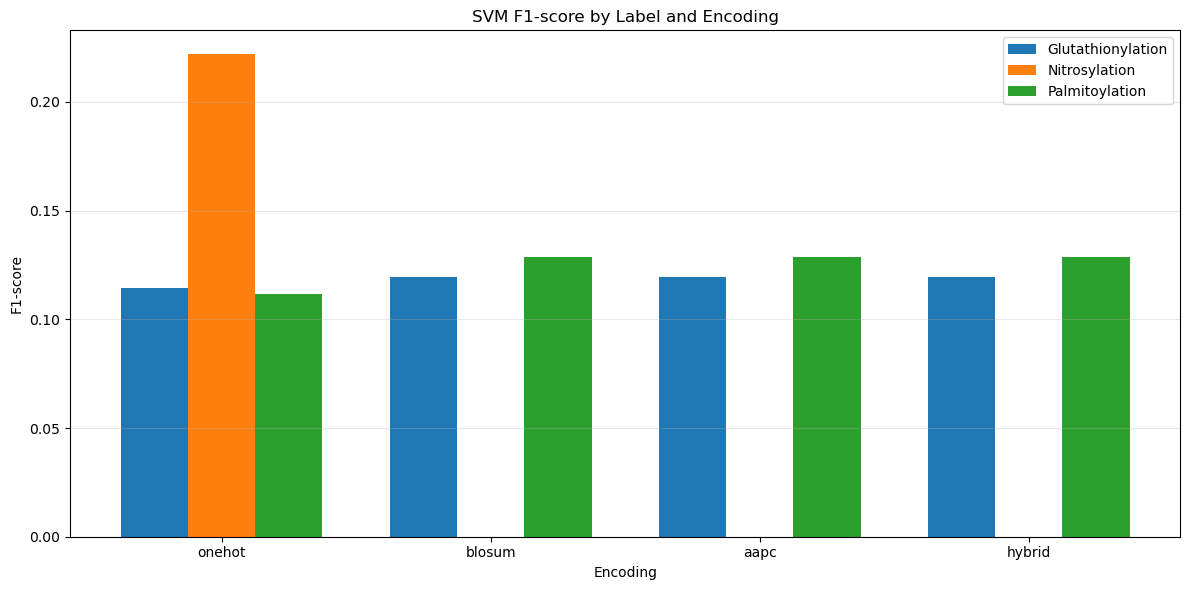

✓ Per-label visualization saved


In [7]:
# Plot 2: Per-label F1 scores across encodings
label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']
label_short = ['Glutathionylation', 'Nitrosylation', 'Palmitoylation']

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(encodings))
width = 0.25

for i, label in enumerate(label_cols):
    f1_values = [all_results[enc]['per_label'][label]['f1'] for enc in encodings]
    ax.bar(x + i*width, f1_values, width, label=label_short[i])

ax.set_xlabel('Encoding')
ax.set_ylabel('F1-score')
ax.set_title('SVM F1-score by Label and Encoding')
ax.set_xticks(x + width)
ax.set_xticklabels(encodings)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../output/svm/visualizations/per_label_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Per-label visualization saved")

## 7. Detailed Results for Each Encoding

Let's examine the detailed performance for each label within each encoding.

In [8]:
for encoding in ENCODINGS:
    if encoding not in all_results:
        continue
    
    print("\n" + "="*80)
    print(f"{encoding.upper()} ENCODING - DETAILED RESULTS")
    print("="*80)
    
    res = all_results[encoding]['per_label']
    
    print(f"\n{'Label':<30} {'F1-score':<12} {'ROC-AUC':<12}")
    print("-" * 54)
    for label in label_cols:
        print(f"{label:<30} {res[label]['f1']:<12.4f} {res[label]['auc']:<12.4f}")
    
    print(f"\n{'Macro Average':<30} {all_results[encoding]['macro_f1']:<12.4f} {all_results[encoding]['macro_auc']:<12.4f}")


ONEHOT ENCODING - DETAILED RESULTS

Label                          F1-score     ROC-AUC     
------------------------------------------------------
S-glutathionylation            0.1145       0.7043      
S-nitrosylation                0.2218       0.7153      
S-palmitoylation               0.1115       0.6871      

Macro Average                  0.1493       0.7022      

BLOSUM ENCODING - DETAILED RESULTS

Label                          F1-score     ROC-AUC     
------------------------------------------------------
S-glutathionylation            0.1196       0.6991      
S-nitrosylation                0.0000       0.7058      
S-palmitoylation               0.1285       0.6656      

Macro Average                  0.0827       0.6902      

AAPC ENCODING - DETAILED RESULTS

Label                          F1-score     ROC-AUC     
------------------------------------------------------
S-glutathionylation            0.1196       0.6991      
S-nitrosylation                0.0000   

## 8. Feature Importance Analysis

For the best-performing encoding, let's examine which features were most important.

**Note:** SVM uses linear coefficients. Higher absolute values indicate more important features.

In [9]:
# Load feature importance for best encoding
best_encoding = summary_df.iloc[0]['Encoding']
print(f"\nFeature Importance for Best Encoding: {best_encoding.upper()}")
print("="*80)

for label in label_cols:
    label_short = label.replace('S-', '').replace('-', '_')
    fi_path = f"../output/svm/{best_encoding}/svm_feature_importance_{label_short}.csv"
    
    if Path(fi_path).exists():
        fi_df = pd.read_csv(fi_path)
        
        print(f"\n{label} - Top 10 Features:")
        print(fi_df.head(10).to_string(index=False))


Feature Importance for Best Encoding: ONEHOT

S-glutathionylation - Top 10 Features:
     feature  importance
   hydro_std   30.285273
 cys_ctx_1_C   18.288812
        aa_A   14.142606
  hydro_mean   14.030714
        aa_S   12.064511
        aa_K   10.346156
   cys_count    9.245282
 cys_ctx_2_C    9.205288
        aa_H    8.102704
cys_ctx_-2_X    7.137861

S-nitrosylation - Top 10 Features:
   feature  importance
 hydro_std   12.655784
      aa_A    9.050677
      aa_N    8.583799
      aa_K    8.514228
      aa_H    6.865822
      aa_E    6.846102
hydro_mean    6.286942
      aa_S    4.904826
      aa_Q    4.480270
 cys_count    3.871397

S-palmitoylation - Top 10 Features:
     feature  importance
   hydro_std   23.736773
 cys_ctx_1_C   18.431556
cys_ctx_-1_K   14.543281
 cys_ctx_2_E   13.636045
cys_ctx_-2_H   12.189595
cys_ctx_-2_M   11.765126
 cys_ctx_1_E   11.443531
        aa_S   10.862479
cys_ctx_-1_R   10.824265
cys_ctx_-1_Q   10.535950


## 9. Summary & Conclusion

In [10]:
print("\n" + "="*80)
print("✓ LINEAR SVM TRAINING COMPLETE FOR ALL ENCODINGS!")
print("="*80)
print(f"\nResults saved to:")
for encoding in ENCODINGS:
    if encoding in all_results:
        print(f"  - ../output/svm/{encoding}/")

print(f"\nSummary saved to:")
print(f"  - ../output/svm/svm_encoding_comparison.csv")
print(f"  - ../output/svm/visualizations/")

print(f"\nBest encoding: {best_encoding}")
print(f"Best Macro F1: {best_f1:.4f}")

print("\n" + "="*80)
print("Next Steps:")
print("1. Compare SVM vs RF vs XGBoost performance")
print("2. Create ensemble combining all three models")
print("3. Try different encodings in ensemble")
print("4. Share predictions with teammates for final ensemble")
print("="*80)


✓ LINEAR SVM TRAINING COMPLETE FOR ALL ENCODINGS!

Results saved to:
  - ../output/svm/onehot/
  - ../output/svm/blosum/
  - ../output/svm/aapc/
  - ../output/svm/hybrid/

Summary saved to:
  - ../output/svm/svm_encoding_comparison.csv
  - ../output/svm/visualizations/

Best encoding: onehot
Best Macro F1: 0.1493

Next Steps:
1. Compare SVM vs RF vs XGBoost performance
2. Create ensemble combining all three models
3. Try different encodings in ensemble
4. Share predictions with teammates for final ensemble
